In [1]:
import pickle
from glob import glob
import os
import yaml
from easydict import EasyDict as edict
import pandas as pd
import networkx as nx
import collections
import numpy as np
from scipy.stats import multivariate_normal
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

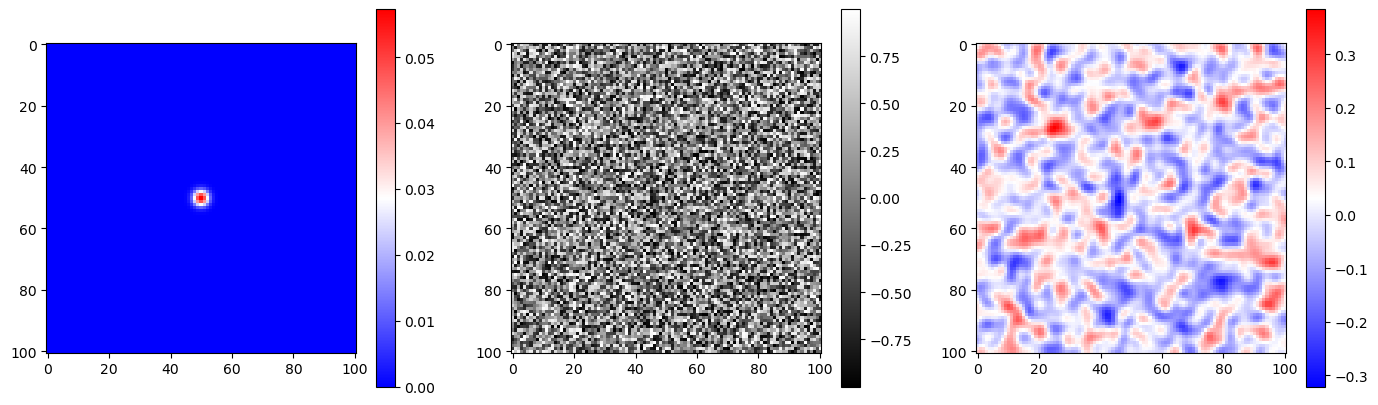

In [3]:
nb = 101
x = np.linspace(-5, 5, nb)
y = np.linspace(-5, 5, nb)
xv, yv = np.meshgrid(x, y)
xy = np.vstack([xv.reshape(-1), yv.reshape(-1)]).T

mvn = multivariate_normal(mean=[0,0], cov=[[1/36,0],[0,1/36]])
gaussian_kernel = mvn.pdf(xy).reshape(nb, nb)
gaussian_kernel /= gaussian_kernel.sum()

init = np.random.uniform(-1,1,size=(101,101))
targets = convolve2d(init, gaussian_kernel, mode='same')
# -------------------------------------------------------------------
f, axes = plt.subplots(nrows=1, ncols=3, figsize=(17,5), dpi=100)
p0 = axes[0].imshow(gaussian_kernel, cmap='bwr')
f.colorbar(p0, ax=axes[0])

p1 = axes[1].imshow(init, cmap='gray')
f.colorbar(p1, ax=axes[1])

p2 = axes[2].imshow(targets, cmap='bwr')
f.colorbar(p2, ax=axes[2])

plt.show()

In [3]:
gaussian_kernel.sum()

100.0

In [36]:
np.random.randint(-1, 2, size=(2,2))

array([[-1,  1],
       [ 0,  0]])